In [1]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
model = SentenceTransformer("clip-ViT-B-32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

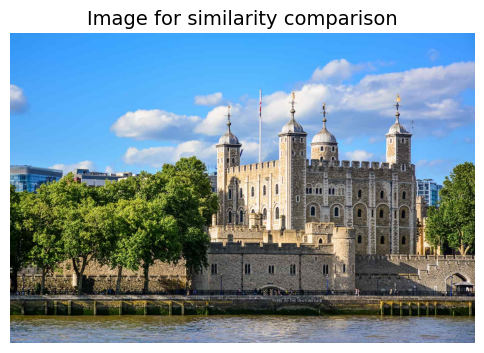

In [2]:
img1 = "/content/ITALY.jpg"
img1 = Image.open(img1)
plt.figure(figsize=(6,6))
plt.imshow(img1)
plt.axis('off')
plt.title('Image for similarity comparison',fontsize=14)
plt.show()

In [3]:
text_description = ["Two dogs in the snow",
                    "A cat on the Table",
                    "A picture of landon at night",
                    "taj mahal view",
                    "A dog sleeping on a couch",
                    "two cats fighting in the garden",
                    "historical us place",
                    "place to visit"]

In [4]:
def display_image_and_compare(image_path,text_description):
  #loading image
  img = Image.open(image_path)

  # encode text and image (converting both the numbers)
  text_emb = model.encode(text_description)
  img_emb = model.encode(img)

  similarity_score = np.dot(text_emb,img_emb.T)

  best_match_index = np.argmax(similarity_score)
  best_match_desc = text_description[best_match_index]

  print(f"\n bestmatch for the image is L{best_match_desc} with score of {similarity_score.max()}")

  plt.figure(figsize=(6,6))
  plt.imshow(img)
  plt.axis('off')
  plt.title('Image for similarity comparison',fontsize=14)
  plt.show


 bestmatch for the image is Lhistorical us place with score of 24.768014907836914


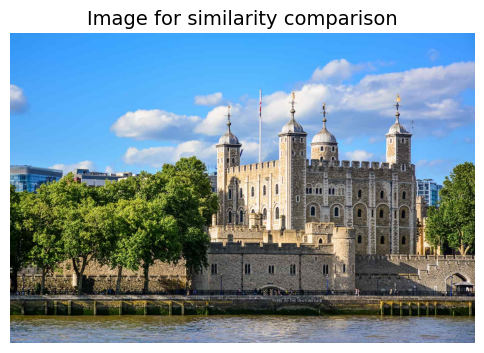

In [5]:
display_image_and_compare("/content/ITALY.jpg", text_description)